# Density functional theory and Localized orbitals

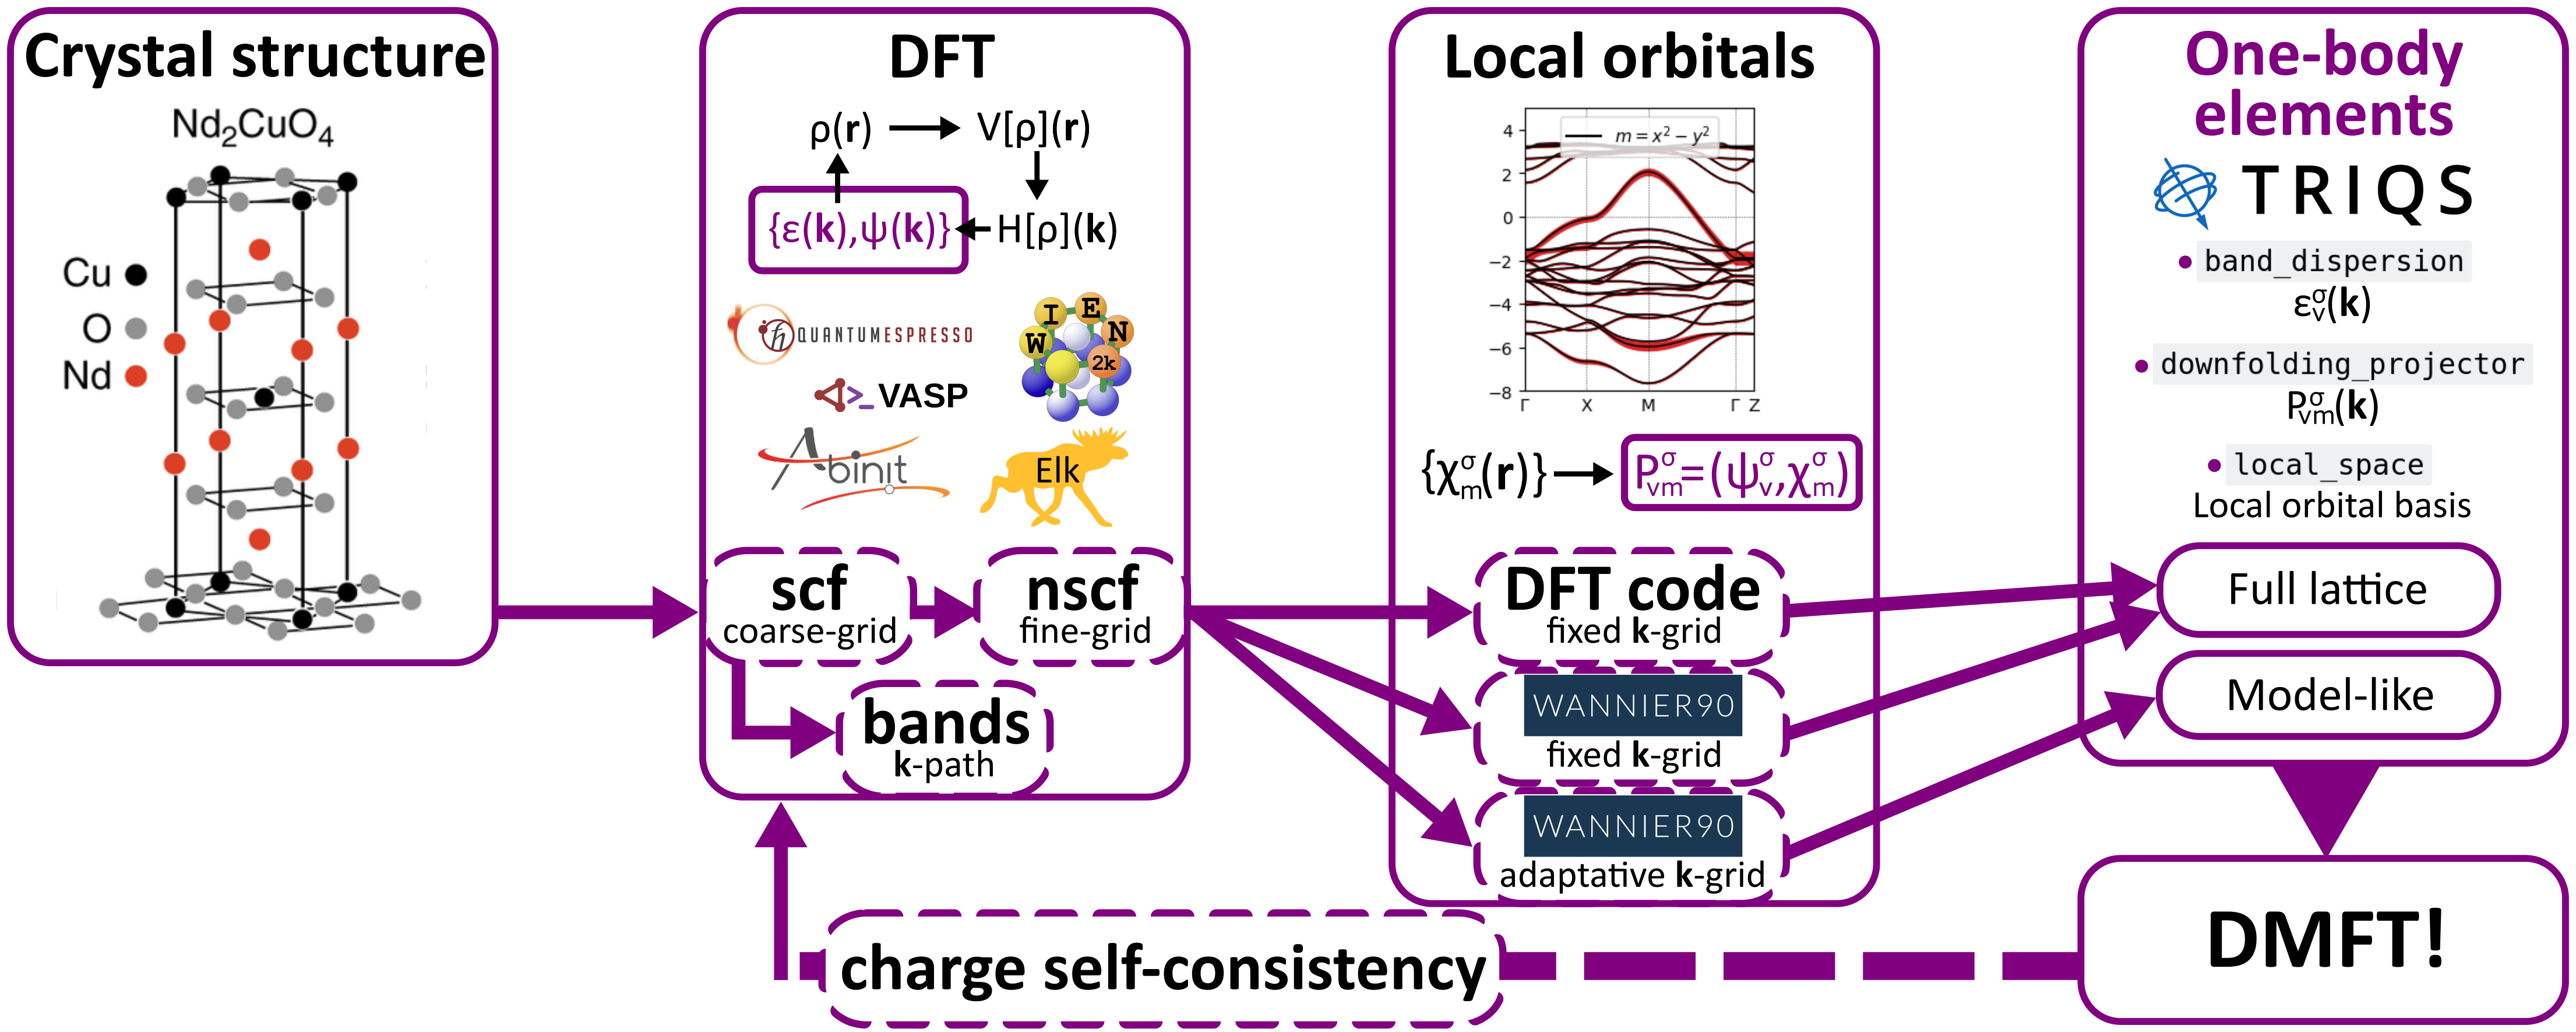

In the combination of density functional theory and dynamical mean-field theory (DFT+DMFT), DFT provides an electronic dispersion $\epsilon^\sigma_\nu$ and a ground-state wave function $| \Psi^\sigma_\nu \rangle$ expressed in the band basis (index $\nu$). While the band basis describes delocalized electrons, DMFT, which at its core is rooted in the concept of locality, requires a set of local orbitals $| \chi^\sigma_m \rangle$. The decomposition of the local orbitals into the band basis is encoded in the projectors, defined as
$$ P^\sigma_{\nu m} = \langle \Psi^\sigma_{\nu} | \chi^\sigma_{m}\rangle. $$
They are useful not only to project the dispersion onto the relevant set of localized orbitals needed for a DMFT problem, but also to embed the resulting self-energy into the whole lattice.

> 🌰  **DFT in a nutshell**: The fundamental variable in DFT is the electron density $\rho(\textbf{r})$. Within the Kohn-Sham formulation of DFT, the interacting many-electron problem is mapped onto a set of non-interacting electrons moving in an effective potential $V_{\text{eff}}[\rho](\textbf{r})$ which is a functional of the electron density. This potential defines an effective single-particle Schrödinger-like equation which can be solved in momentum space as 
$$ H^{\text{DFT}}[\rho](\textbf{k}) |\psi^\sigma_{\nu} (\textbf{k}) \rangle = \epsilon^\sigma_\nu(\textbf{k}) | \psi^\sigma_{\nu}(\textbf{k}) \rangle $$
where $\epsilon^\sigma_\nu(\textbf{k})$ and $|\psi^\sigma_\nu(\textbf{k}) \rangle$ are the electronic dispersion and wavefunctions, respectively, labeled by crystal momentum $\textbf{k}$, band index $\nu$ and diagonal spin-like index $\sigma$. A new density is given by $\rho(\textbf{k}) = \sum_{\sigma\nu} \langle \psi^\sigma_\nu(\textbf{k}) | \psi^\sigma_\nu(\textbf{k}) \rangle$, and the following loop is solved until convergence of the density:
$$
~\\
\begin{array}{ccc}
   \rho(\textbf{r}) & \longrightarrow & V[\rho](\textbf{r}) \\
   \uparrow & & \downarrow \\
   \{ \epsilon^\sigma_\nu(\textbf{k}) \}, \ \{ |\psi^\sigma_\nu(\textbf{k}) \rangle \} & \longleftarrow & H[\rho](\textbf{k})
\end{array}
$$

When performing a DFT calculation, the first step is to obtain a **self-consistently** converged electronic density $\rho$ on a decent **k**-point grid. From this density, we can easily construct the potential $V[\rho]$ on a different **k**-point grid and solve only once (**non-self-consistently**).

This tutorial demonstrates how to perpare a DMFT calculation starting from a crystal structure. The procedure includes 1) using DFT to obtain a converged electronic density for a given crystal structure, 2) obtaining the DFT electronic dispersion and inspecting the orbital character, 3) constructing an adequate set of localized orbitals and 4) loading the resulting objects using the **one-body element** object of TRIQS/ModEST.

In this tutorial, we use the plane-wave pseudopotential DFT code [Quantum ESPRESSO](https://www.quantum-espresso.org) and as an example, we investigate La$_2$CuO$_4$. In the interest of time, we provide all of the input and important output files related to DFT and wannierization. However, for completeness and reproducibility, this section outlines the full procedure step by step.

## 🧮 1. Density-functional theory with Quantum ESPRESSO

The first step is to obtain the self-consistently converged electronic density.

#### 🔧 Quantum ESPRESSO input file

The input file for this calculation is located at: ``data/scf/lco.scf.in``. Note that for more details about the parameters or Quantum Espresso in general, we refer the reader to [the official tutorials of the software](https://www.quantum-espresso.org/tutorials/).

Quantum ESPRESSO input files are organized into several sections:
- ``&control``, ``&system``, and ``&electrons`` define the type of calculation along with computational options;
- `ATOMIC_SPECIES` details the different atoms in the unit cell and their respective pseudopotentials;
- `CELL_PARAMETERS` defines the translational lattice vectors of the unit cell;
- `ATOMIC_POSITIONS` are the position of each atom in the unit cell in units of the translational lattice vectors;
- `K_POINTS` defines the **k**-point grid.

We perform a **self-consistent field (SCF)** run (``calculation = 'scf'``), which means the DFT equations will be solved iteratively until the charge density is converged. Three key parameters require convergence checks:
- ``ecutwfc`` (``ecutrho``): **Plane-wave basis** cutoff energy for the wavefunction (density);
- ``K_POINTS``: Definition of the **Brillouin zone**;
- `degauss`: Effective **smearing temperature** important for metallic or small-gap systems to ensure smooth convergence.

#### ▶️ Running the SCF calculation

Quantum ESPRESSO provides a suite of executables for performing different types of calculations. To run the SCF calculations we use the `pw.x` executable with the following command in the terminal:
```bash
pw.x < lco.scf.in > lco.scf.out  # write output directly to file
```
> 💡 **Tip**: You can monitor convergence in `lco.scf.out` by tracking the total energy. For example, ``grep Energy lco.scf.out``.

## 📈 2. Band structure and orbital character calculation with Quantum ESPRESSO

Using the converged density from the previous SCF calculation, we can now compute the Kohn-Sham eigenvalues for any **k**-point in a single pass. First, we compute the **band structure**, the eigenvalues of the Kohn-Sham Hamiltonian along a high-symmetry path in the Brillouin zone, to better understand the low-energy electronic structure. We also examine the **orbital character** of the bands close to the Fermi level.

This section has three parts:
1. Compute the Kohn-Sham eigenvalues along a high-symmetry path;
2. Extract band information;
3. Calculate the overlap between the resulting wave functions and hydrogen-like orbitals at the atomic positions.

After that, we will have all the information needed to plot the band structure with the orbital characters.

### ⚙️ 2.1 High-symmetry path
The band structure is computed by taking a converged density to construct a new potential, then solve the Kohn-Sham Hamiltonian in a single pass (**non-self-consistent field (NSCF)** calculation) along a **user-defined path of k-points** in reciprocal space.

The input file for this calculation is located at: ``data/bands/lco.bnd.in``. It is similar to the previous input file, but with three important differences:
- `calculation` set to `'bands'`: instructs Quantum Espresso to perform an NSCF calculation for the bands;
- `diago_full_acc` set to `.true.`: ensures full diagonalization of the Kohn-Sham Hamiltonian, instead of using iterative or approximate solvers;
- `K_POINTS crystal_b`: specifies the high-symmetry path in units of the reciprocal lattice vectors, with the last integer of each line the number of points per segment.

> 💡**Note**: The Brillouin zone here corresponds to the **body-centered tetragonal** structure of La$_{2}$CuO$_{4}$ (space group I4/mmm). The high-symmetry points are chosen accordingly to reproduce the familiar two-dimensional band structure one would get from a tight-binding model on the square lattice.

#### ▶️ Run the band structure calculation
With the input file and `scf` calculation ready, we run this `bands` calculation using:
```bash
pw.x < lco.bnd.in > lco.bnd.out
```

### ⚙️ 2.2 Extracting the bands information
The previous calculation generates data that is difficult to visualize. Fortunately, Quantum Espresso provides an executable for this: `bands.x`. Its input file is located at: ``data/bands/lco.bands.in``, and contains the path to the required information, as well as the file to which it writes the data to be plotted. 

#### ▶️ Run the bands post-processing
The executable was run with:
```bash
bands.x < lco.bands.in > lco.bands.out
```
#### 🧠 Output file
The output file is located at: `data/bands/lco.bands`. Each block corresponds to a single band with index $\nu$, with each line corresponding to the information for a **k**-point along the high-symmetry path. The first entry is the $x$-value along the high-symmetry path and the second is the eigenvalue $\epsilon_{\nu}(\textbf{k})$. In our calculation, only one spin was considered.

### ⚙️ 2.3 Orbital character
The pseudopotentials that define the atoms in `ATOMIC_SPECIES` of the scf file contains information about atomic-like orbitals as **real spherical harmonics**. Thus, Quantum Espresso can utilize the wave functions representing the ground state at a given **k**-point and project them onto those atomic orbitals. In other words, given 
1. $|\Psi^\sigma_{\nu} (\textbf{k}) \rangle$ the wave function of a band $\nu$ with spin $\sigma$ at **k** computed in the step 2.1 and
2. $| \tilde \chi^{\textbf{R}}_{lm} (\textbf{k}) \rangle$ the Bloch transform of an atomic orbital with quantum number $l$ and $m$ of the atom at the position **R**,
   
the orbital character of the band $\nu$ with spin $\sigma$ at **k** in the $lm$ channel of the atom at **R** is given by
$$ \Big|\langle \Psi^\sigma_\nu (\textbf{k}) | \tilde{\chi}^{\textbf{R}}_{lm} (\textbf{k}) \rangle \Big|^2.$$

These orbital characters are calculated using the `projwfc.x` executable of Quantum Espresso. The input file is located at: ``data/fatbands/lco.kpdos.in``. We now use the card `&projwfc` and the `projwfc.x`executable to compute the projections of the wave functions.

#### ▶️ Run the band structure calculation
This calculation was performed using:
```bash
projwfc.x < lco.kpdos.in > lco.kpdos.out
```

#### 🧠 Output file
In the `fatbands/` directory, you can find a file named `lco.proj.dat.projwfc_up` containing the orbital characters of each band at each **k**-point along the high-symmetry path. The first important line is `1    1 La   5S     1    0    1`, which starts the first (*1*) block of orbital characters of the atom #*1* of *La* type for the *5S* orbital characters, the first (*1*) shell with $l=0$ and index $m = 1$. The next 8040 lines are the associate characters for the 201 kpts and 40 bands (201*40=8040) of this calculation.

To extract the $3d_{x^2-y^2}$ of the copper atom #3, we run the following command:
```bash
grep "3 Cu   3D" -A 8040 lco.proj.dat.projwfc_up | grep -v "Cu" > fatbands.dat
```

This data is now stored in the `data/fatbands/fatbands.dat` file.

We address plotting the results in Section 4 of this tutorial. Find below already a previous for the orbital character in the Cu-$3d_{x^2-y^2}$ channel. This orbital dominates the only band crossing the Fermi level. It serves as a good candidate for a single-band model of La$_2$CuO$_4$, which we will construct in the next section.

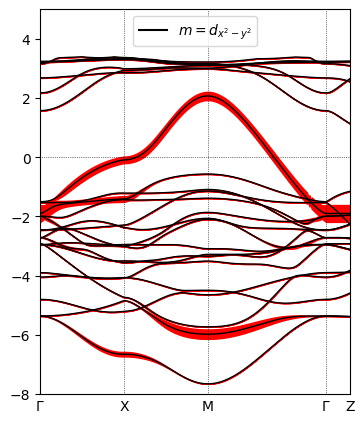

## 🔗 3. Quantum Espresso interfaced with Wannier90

To connect DFT to DMFT, we need to construct a set of localized orbitals. Using the orbital character information of the bands around the Fermi level, we decide to extract from DFT a single-band model of the Cu $3d_{x^2-y^2}$ orbital. To construct the corresponding low-energy tight-binding model Hamiltonian, we use the Wannier90 code. For more information about the procedure, please refer to the [Wannier90 publication](https://iopscience.iop.org/article/10.1088/1361-648X/ab51ff/pdf) or [see a tutorial](https://docs.epw-code.org/_downloads/f2f39ac545ca12dc2838f7359b3633a9/Mon.4.Pizzi.pdf).

> **Wannier90 in a nutshell**: Electronic structures of periodic systems are conventionally represented in a Bloch basis $\psi_{\nu\textbf{k}}(\textbf{r}) = u_{\nu\textbf{k}}(\textbf{r})e^{-i\textbf{k} \cdot \textbf{r}}$ where $\nu$ is a band index, $\textbf{k}$ a momentum defined in the Brillouin zone and $u_{\nu\textbf{k}}(\textbf{r}) = u_{\nu\textbf{k}}(\textbf{r}+\textbf{R})$ is a periodic function under translation by a Bravais vector $\textbf{R}$. Wannier functions are a set of orthonormal functions $w_{n\textbf{R}}(\textbf{r})$ that are spatially localized in real space and formally correspond to unitary transformations of the Fourier transforms of Bloch states. These unitary transformations include a gauge freedom that can be optimized to maximally localize the Wannier functions by minimizing their spread in space. This spread can be expressed in terms of the overlap matrix $M^{(\textbf{k}, \textbf{b})}_{\nu\nu'} = \langle u_{\nu\textbf{k}} | u_{\nu',\textbf{k}+\textbf{b}} \rangle$ and an initial projection on trials orbitals. These quantities are computed by the DFT program and Wannier90 uses them to find the set of orbitals. A final Wannier Hamiltonian is obtained by computing the overlap of the resulting orbitals.

We now construct a single-Wannier orbital model for La$_2$CuO$_4$. We will first write the Wannier90 input file, and then run the appropriate set of commands.

#### 📝 3.1 Create the Wannier90 input file

The input file that we have used for this tutorial can be found here: ``data/mlwf/lco.win``.

First, it includes information about the translational lattice vectors (`unit_cell_cart`) and the atomic structure and positions (`atoms_cart`). It will also read the wavefunctions from an NSCF calculation: the ``mp_grid`` and ``kpoints`` specifies the **k**-grid.

Second, it specifies which bands are being considered with `num_bands` their number and `exclude_bands` those excluded.

Third, the important physical choice consists of the selected localized orbitals. Here we have:
```bash
num_wann = 1
begin projections
Cu:dx2-y2:x=1,0,0
end projections
```
which indicates we want to construct a single Wannier orbital, centered at the Cu atom, with the $d_{x^2-y^2}$ character where $x$ is defined along the $(1, 0, 0)$ direction. 

Fourth, the file contains data about plotting for postprocessing purposes. In particular, we are interested in plotting the resulting band structure in the orbital basis.

Finally, `write_hr = true` and `write_tb = true` are required to produce the Hamiltonian $H(\textbf{r})$ in its tight-binding form. Those files are essential for connecting to ModEST.

#### 🚀 3.2 Running the calculations

The first step is to compute an NSCF calculation on the same **k**-point grid as specified in the Wannier90 input file. We use the following file: ``data/mlwf/lco.nscf.in``. We run with
```bash
pw.x < lco.nscf.in > lco.nscf.out
```

From this information, Wannier90 performs a preprocessing step, where it determines which elements of the overlap matrix $M^{(\textbf{k}, \textbf{b})}_{\nu\nu'}$ it will need. We run with
```bash
wannier90.x -pp lco
```

Wannier90 finds the ``lco.win`` using the seedname ``lco`` provided in the command.

Next, we use Quantum Espresso to computes the required elements of the overlap matrix. This is done using:
```bash
pw2wannier90.x < lco.pw2wan.in > lco.pw2wan.out
```

Finally, we run Wannier90 in full mode, where it minimizes the spread of the Wannier orbitals and produces a final tight-binding Hamiltonian in the set of localized orbitals. We run:
```bash
wannier90.x lco
```

## 🧩 4. Exercises

Now that we have run both the **DFT** and **Wannier90 interpolation**, we are ready to compare them and build our low-energy tight-binding model. This will validate how well the low-energy tight-binding model reproduces the _ab-initio_ Kohn-Sham bands -- a key sanity check before beginning the DMFT calculation.

We'll write a Python code step-by-step to: 
1. Load and reshape the band structure data
2. Plot the band structure data
3. Load the Wannier90 data and overlay the Wannier model on the DFT bands.

Let's build the plot one step at a time:

### 🧪 Exercise 1: Load and reshape the DFT band structure data
The file ``data/bands/lco_bands.data.gnu`` contains a column of $(k, E)$ pairs. Load the data and reshape it into a 2D array of shape ``(n_bands, n_kpts)``.
> 💡 **Tips**
> - The numpy library has a utility function ``numpy.loadtxt`` for reading text files.
> - The $k$-points are repeated for each band, so you can get the unique k-points by calling ``numpy.unique``.
> - It is often helpful to ``reshape`` the eigenvalues into an array with shape (n_bands, n_kpts).

In [1]:
import numpy as np 

filename1 = '../data/bands/lco_bands.dat.gnu'
filename2 = '../data/fatbands/fatbands.dat'

# Step 1: load the DFT data
data1 = np.loadtxt(filename1)
data2 = np.loadtxt(filename2)

# Step 2: separate the k-points and eigenvalues
kpts = np.unique(data1[:,0])
bands = data1[:,1].reshape(-1, len(kpts))

# load the orbital character from the second file and swap the axes
orbital_char = 0.3*data2[:, 2].reshape(5, len(kpts), len(bands)).swapaxes(1,2)

### 🧪 Exercise 2: Plot the DFT band structure
Use ``matplotlib`` and our custom ``matplotlib.axes`` functions (``plot_band_structure``) to visualize the DFT band structure. The band structure is defined with respect to the Fermi level, which can be obtained from ``data/scf/lco.scf.out``.

> 💡 **Tip**: Most DFT codes write lots of information to their output files, thus the Unix program ``grep`` is an extremely useful tool to grab quick information. For the Fermi level, you can run ``grep Fermi data/scf/lco.scf.out``

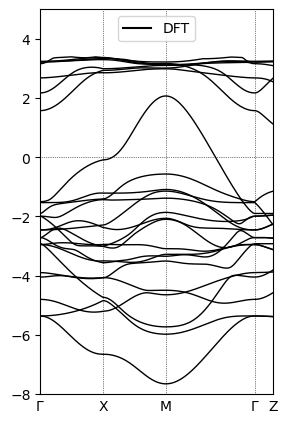

In [2]:
import matplotlib.pyplot as plt
from triqs_tutorials_utils.mpl_interface import plot_band_structure

# Fermi level (grep Fermi data/scf/lco.scf.out)
eF =  12.7367

plt.figure(figsize=(3,5))

# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']


# use kpts and bands from Exercise 1
plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)

plt.plot([], [], color='k', label='DFT')
plt.legend(loc='upper center', ncols=2, fontsize=10)
plt.ylim(-8, 5)

plt.show()

### 🧪 Exercise 3: Plot "Fat Bands"

Now that you've successfully plotted the DFT band structure, we will plot the band structure with the orbital content overlaid, often called "fatbands". This is a typical practice to identify the dominant orbital content of a Kohn-Sham state at a specific energy and **k**-point. In this exercise, loop over the orbital characters (``orbital_char`` loaded in Exercise 1) and pass the band structure data along with the orbital character data to plot the fat bands. The orbitals are ordered as: $d_{z^2}$, $d_{xz}$, $d_{yz}$, $d_{x^2-y^2}$ and $d_{xy}$.

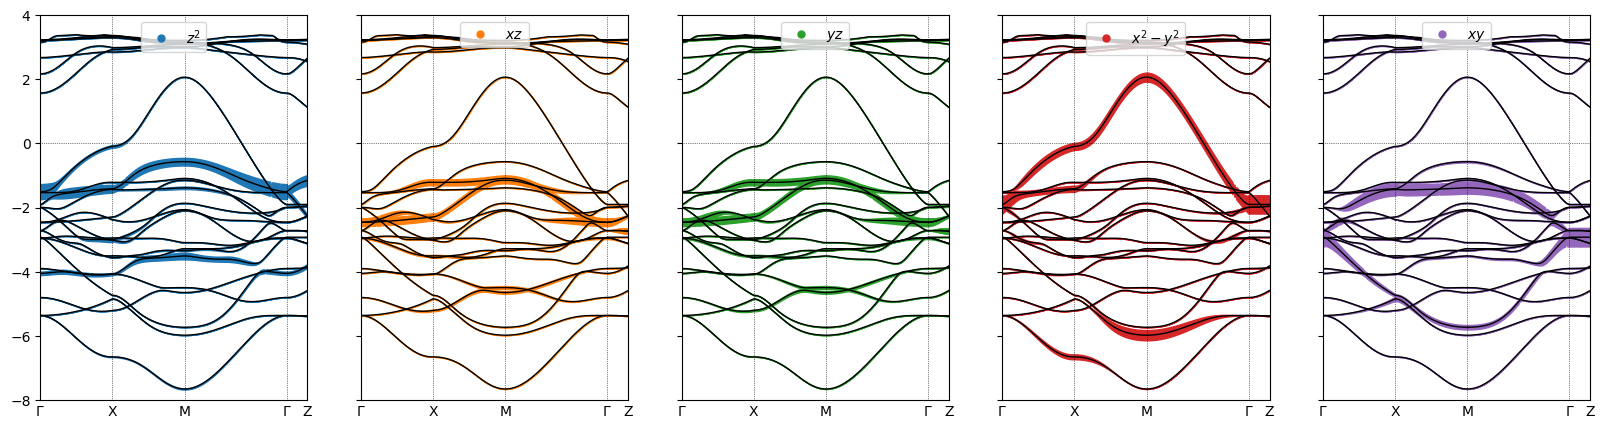

In [3]:
fig, ax = plt.subplots(1, 5, figsize=(20,5),sharey=True)

# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']

orbital_labels = ['z^{2}', 'xz', 'yz', 'x^{2}-y^{2}', 'xy']

for (i, orb) in enumerate(orbital_labels):
    # use kpts and bands from Exercise 1
    plot_band_structure(kpts, bands, 
                        orb_char=orbital_char[i], 
                        axes=ax[i], 
                        orb_char_color=f"C{i}",
                        fermi_level=eF, 
                        high_symm_points=high_symm_points, 
                        high_symm_labels=high_symm_labels)
    
    ax[i].plot([], [], 'o', ms=5, color=f"C{i}", label=r'$%s$' %orb)
    ax[i].legend(loc='upper center', ncols=2, fontsize=10)
    ax[i].set_ylim(-8, 4)
plt.show()

### 🧪 Exercise 4: Tight-binding from Wannier90 using TRIQS

Now that we have familiarized ourselves with the DFT data by plotting the band structure and analyzing the orbital content of the bands, we can construct our local orbitals. We choose to use maximally-localized Wannier functions to create a local orbital for the Cu-$d_{x^2-y^2}$ orbital. As outlined above, this procedure gives a real-space Hamiltonian, $H(\textbf{r})$. We will use this Hamiltonian as our non-interacting tight-binding model to which we will then add local interactions.

**We are now at the interface between DFT and TRIQS.** Let's load our DFT data, or more generally our one-body physics data, into a TRIQS object called ``one_body_elements``. One-body elements abstracts away the one-body physics into a single object that can be used when writing DMFT loops. For this case, the one-body physics consists of the dispersion (in the form of a tight-binding Hamiltonian) and a local space. The local space corresponds to a definition of local (atomic-like) orbitals.

Run the cell below to produce the band structure for our tight-binding model. We will explain all of the pieces in much more detail in the next tutorial.

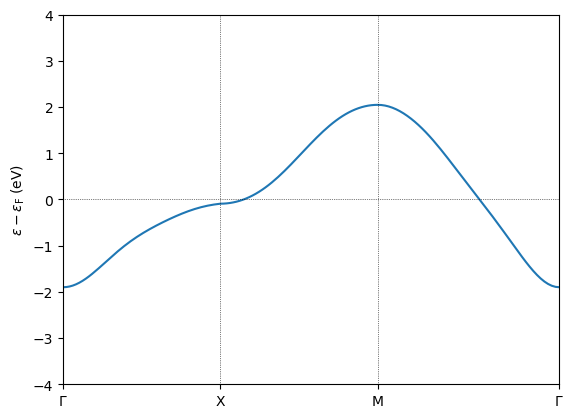

In [4]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path

# high-symmetry points in bct zone
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]

# create high-symmetry path
segments = [(G,X), (X,M), (M, G)]
k_points, k_lin, k_ticks = k_space_path(segments, num=50)

# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("../data/mlwf/lco",  "NonPolarized", [modest.AtomicOrbs(l=2,dim=1,dft_idx=0,cls_idx=0)])

# compute the dispersion along the high-symmetry directions
e_k = obe.H[0](k_points).real.reshape(1,-1)

# plot the dispersion and decorate
plt.plot(k_lin, e_k[0,:] - eF)
for k in k_ticks: plt.axvline(k, color='k', lw=0.5, ls='dotted')
plt.axhline(0, color='k', lw=0.5, ls='dotted')
plt.xticks(k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$'])
plt.ylim(-4,4); plt.xlim(min(k_lin), max(k_lin))
plt.ylabel(r'$\varepsilon-\varepsilon_{\mathrm{F}}$ (eV)')
plt.show()

### 🧪 Exercise 5: Summarize

Let's take a moment to describe our results in a bit more detail. In a few sentences, can you describe the most salient features of the band structure of La$_2$CuO$_4$, as well as the features of our low-energy model?

The band structure of La$_{2}$CuO$_{4}$ shows a dispersive two-dimensional band derived from the Cu-$d_{x^{2}-y^{2}}$ orbital at low energy. The overall bandwidth $W$ spans around $\sim 4$ eV. The remaining complex bands are formed from the hybridized O($2p)$ and Cu($3d$) orbitals. There are a total of 17 bands (5 Cu and 12 O).

## 🎉 Nice!

You've finished the exercises for this tutorial! Now you are ready to start building your DMFT calculation.